# NLP（Natural Language Processing（自然语言处理））
> 处理和理解自然语言，包括文本生成、机器翻译、文本分类、问答与信息抽取等。
> 代表模型：Google（BERT、T5）、OpenAI（GPT系列）、Meta AI（LLaMA）

泛指所有处理和理解人类语言的AI技术，涵盖文本分析、生成、翻译等任务。
- 理解任务（如分类、问答）：侧重分析文本语义。
- 生成任务（如翻译、摘要）：侧重输出自然语言内容。
- 语义相关任务（如相似度、检索）：侧重衡量文本间关系。

# 1. 常见任务
1. Text Classification（文本分类）【*】：将文本归类到预定义的类别中（如情感分析、垃圾邮件检测）。
2. Token Classification（标记分类）【*】：对文本中的每个词或子词（token）进行分类，例如命名实体识别（NER）、词性标注（POS）。
3. Table Question Answering（表格问答）：基于结构化表格数据回答问题（如从Excel表格中提取特定信息）。
4. Question Answering（问答系统）：从给定文本中抽取或生成问题的答案（如阅读理解任务）。
5. Zero-Shot Classification（零样本分类）：无需特定训练数据，直接根据文本描述分类新类别（如判断一段文本是否涉及“政治”或“体育”）。
6. Translation（翻译）：将文本从一种语言自动翻译成另一种语言（如英译中）。
7. Summarization（文本摘要）【*】：生成输入文本的简短摘要（抽取式或生成式）。
8. Feature Extraction（特征提取）：将文本转换为向量表示（嵌入向量），用于检索、聚类或下游任务。
9. Text Generation（文本生成）：根据输入生成连贯文本（如故事续写、对话生成、代码生成）。
10. Fill-Mask（掩码填充）：预测并填充句子中被遮蔽的词语（如"巴黎是[MASK]的首都" → "法国"）。
11. Sentence Similarity（句子相似度）：计算两段文本的语义相似度（如用于检索或去重）。
12. Text Ranking（文本排序）：根据相关性对文本列表进行排序（如搜索引擎结果排序）。

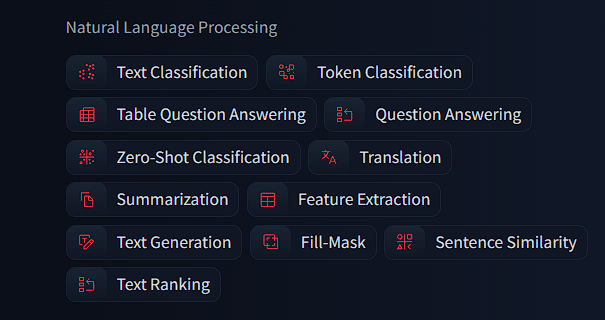

# 2. 文本分类（Text Classification）
## 1. 常见场景
1. 情感分析（Sentiment Analysis）
判定文本的情感倾向（正面、中性、负面，或更细分类如愤怒、开心等）
- 例子：电商评价、社交舆情监控
- 模型示例：`distilbert-base-uncased-finetuned-sst-2-english`、`cardiffnlp/twitter-roberta-base-sentiment`

2. 主题分类（Topic Classification）
将文本按主题分类，比如财经、科技、体育、娱乐
- 例子：新闻分拣、垃圾邮件检测中的主题判别
- 模型示例：`facebook/bart-large-mnli（可以做零样本分类）`、`joeddav/xlm-roberta-large-xnli`

3. 垃圾邮件 / 恶意内容检测
包括：
- Spam detection（垃圾邮件）
- Toxic content detection（辱骂/仇恨言论检测）

模型示例：`unitary/toxic-bert`、`facebook/roberta-hate-speech-detection`

4. 意图识别（Intent Classification）
在对话系统或客服机器人中，识别用户的意图类型
- 例子：机票预订、问天气、账户查询等
- 模型示例：`bert-base-uncased-fine-tuned-on-SNIPS`、`microsoft/DialogRPT`

5. 产品/服务类别分类
- 用途：电子商务、内容推荐系统中区分商品或服务类别
- 例子：服装、数码、食品等分类

6. 法律/医疗文本分类
- 法律领域的案件类型分类
- 医疗领域的临床笔记分类
- 例子：`legal-bert-base`（法律领域），`biobert`（生物医学领域）

7. 多标签分类（Multi-Label Classification）
一篇文本可能同时属于多个类别
- 例子：一篇新闻既是“体育”又是“国际”
- 模型示例：`任意 BERT / RoBERTa 模型 fine-tune 成多标签任务`


8. 扩展：以上功能按训练方式划分
大模型在文本分类中有几种常见使用方式：
1. 微调（Fine-tuning）
- 将预训练模型如 BERT/RoBERTa 在特定任务数据集上进行参数更新
- 好处：性能好，适应性高
- 成本：需要标注数据+训练资源

2. 零样本分类（Zero-shot Classification）
- 不在目标数据集上训练，通过自然语言描述类别名称让模型直接推理
- 例子：facebook/bart-large-mnli + Hugging Face pipeline("zero-shot-classification")
- 好处：无需标注数据，快速上线
- 成本：速度相对慢，依赖模型能力

3. 少样本/提示学习（Few-shot / Prompt-based）
- 用少量样本结合提示（prompt）进行预测
- 例子：用 ChatGPT 给出判断“这句话情感是积极还是消极”

In [1]:
from transformers import pipeline

# 二分类
# 创建文本分类pipeline
classifier = pipeline("text-classification",
                     model='distilbert/distilbert-base-uncased-finetuned-sst-2-english',
                     top_k=None
                     )

# 分析文本情感
result = classifier("This movie is absolutely fantastic! The acting was superb.")
print(result)

D:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12147.92it/s]


[[{'label': 'POSITIVE', 'score': 0.9998739957809448}, {'label': 'NEGATIVE', 'score': 0.00012604561925400048}]]


In [1]:
from transformers import pipeline

# 多情感分析
classifier = pipeline("text-classification",
                      model='bhadresh-savani/bert-base-uncased-emotion', 
                      top_k=None)
prediction = classifier("I love using transformers. The best part is wide range of support and its easy to use", )
print(prediction)

D:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 9967.90it/s]


[{'label': 'joy', 'score': 0.9972521662712097}]


# 3. 文本摘要（Text Summarization）
文本摘要是大语言模型（LLM）非常常见的应用场景之一，指将长文本压缩成短文本，同时保留关键信息。
## 1. 常用模型
| 模型名称 |	类型 |	语言 |	适用场景 |
| ----- | ---- |  ----- | ---- |
| facebook/bart-large-cnn |	生成式 |	英文 |	新闻 |
| google/pegasus-xsum |	生成式 |	英文 |	短摘要 |
| t5-base |	生成式 |	英/多语 |	自定义摘要任务 |
| allenai/led-base-16384 |	生成式 |	英文 |	长篇文档 |
| facebook/mbart-large-50 |	生成式 |	多语言 |	多语摘要 |
| IDEA-CCNL/Randeng-BART-139M |	 生成式 |	中文 |	中文新闻/文档 |
| sentence-transformers |	抽取式 |	多语言 |	任意场景 |


In [2]:
!pip install tiktoken sentencepiece protobuf==3.20.3

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import re
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

ARTICLE = """ New York (CNN)When Liana Barrientos was 23 years old, she got married in Westchester County, New York.
A year later, she got married again in Westchester County, but to a different man and without divorcing her first husband.
Only 18 days after that marriage, she got hitched yet again. Then, Barrientos declared "I do" five more times, sometimes only within two weeks of each other.
In 2010, she married once more, this time in the Bronx. In an application for a marriage license, she stated it was her "first and only" marriage.
Barrientos, now 39, is facing two criminal counts of "offering a false instrument for filing in the first degree," referring to her false statements on the
2010 marriage license application, according to court documents.
Prosecutors said the marriages were part of an immigration scam.
On Friday, she pleaded not guilty at State Supreme Court in the Bronx, according to her attorney, Christopher Wright, who declined to comment further.
After leaving court, Barrientos was arrested and charged with theft of service and criminal trespass for allegedly sneaking into the New York subway through an emergency exit, said Detective
Annette Markowski, a police spokeswoman. In total, Barrientos has been married 10 times, with nine of her marriages occurring between 1999 and 2002.
All occurred either in Westchester County, Long Island, New Jersey or the Bronx. She is believed to still be married to four men, and at one time, she was married to eight men at once, prosecutors say.
Prosecutors said the immigration scam involved some of her husbands, who filed for permanent residence status shortly after the marriages.
Any divorces happened only after such filings were approved. It was unclear whether any of the men will be prosecuted.
The case was referred to the Bronx District Attorney\'s Office by Immigration and Customs Enforcement and the Department of Homeland Security\'s
Investigation Division. Seven of the men are from so-called "red-flagged" countries, including Egypt, Turkey, Georgia, Pakistan and Mali.
Her eighth husband, Rashid Rajput, was deported in 2006 to his native Pakistan after an investigation by the Joint Terrorism Task Force.
If convicted, Barrientos faces up to four years in prison.  Her next court appearance is scheduled for May 18.
"""
model_name = "csebuetnlp/mT5_multilingual_XLSum"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

input_ids = tokenizer(
    ARTICLE,
    return_tensors="pt",
    padding="max_length",
    truncation=True,
    max_length=512
)["input_ids"]

output_ids = model.generate(
    input_ids=input_ids,
    max_length=84,
    no_repeat_ngram_size=2,
    num_beams=4
)[0]

summary = tokenizer.decode(
    output_ids,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)

print(summary)


Loading weights: 100%|██████████| 284/284 [00:00<00:00, 34079.54it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


A woman has pleaded not guilty to making false statements about her marriage.


## 4. 命名实体识别（ner）
定义：命名实体识别是一种自然语言处理（NLP）任务，用来从文本中识别并分类特定类型的“实体”，例如：
- 人名（Person）
- 地名（Location）
- 机构名（Organization）
- 时间（Time）
- 产品、货币数值、生物名词等


目标：输出文本中每个实体所在位置及其类型标签。

In [1]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline

tokenizer = AutoTokenizer.from_pretrained("dslim/bert-base-NER")
model = AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER")

nlp = pipeline("ner", model=model, tokenizer=tokenizer)
example = "My name is Wolfgang and I live in Berlin"

ner_results = nlp(example)
print(ner_results)


D:\Program Files\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7447.26it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     | Details
-------------------------+------------+--------
bert.pooler.dense.weight | UNEXPECTED |        
bert.pooler.dense.bias   | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity': 'B-PER', 'score': np.float32(0.9990139), 'index': 4, 'word': 'Wolfgang', 'start': 11, 'end': 19}, {'entity': 'B-LOC', 'score': np.float32(0.999645), 'index': 9, 'word': 'Berlin', 'start': 34, 'end': 40}]
